<a href="https://colab.research.google.com/github/Abdulrahman1103/coffee-website/blob/main/Loading%20dataset%20from%20csv%20file%20on%20Google%20Drive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from scipy.stats import zscore

In [22]:
from google.colab import drive

# Load the Drive helper and mount
project_path= "/content/drive/MyDrive/Colab Notebooks/COMP 441 ML Labs/Lab (5)/" # Set up you project path here
dataset_path= project_path + "Auto.csv"


drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
dataset_path = "Auto.csv" # Corrected path
dataframe = pd.read_csv(dataset_path)

# Display the first few rows
print("First few rows of the dataset:")
dataframe.head()

First few rows of the dataset:


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [24]:
url = 'https://raw.githubusercontent.com/plotly/datasets/master/auto-mpg.csv'  # Update the URL
dataframe = pd.read_csv(url)


In [25]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    396 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model-year    398 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 21.9 KB


In [30]:
dataframe = dataframe.drop(['year','origin', 'name', 'cylinders'], axis=1)
# Display the first few rows after removing Latitude and Longitude
print("First few rows of the dataset without year','origin', and 'name':")
dataframe.head()

First few rows of the dataset without year','origin', and 'name':


,mpg,displacement,horsepower,weight,acceleration
0,18.0,307.0,130,3504,12.0
1,15.0,350.0,165,3693,11.5
2,18.0,318.0,150,3436,11.0
3,16.0,304.0,150,3433,12.0
4,17.0,302.0,140,3449,10.5


In [31]:
numerical_features = dataframe.select_dtypes(include=np.number).columns
print("Numerical Features:", numerical_features)

Numerical Features: Index(['mpg', 'displacement', 'weight', 'acceleration'], dtype='object')


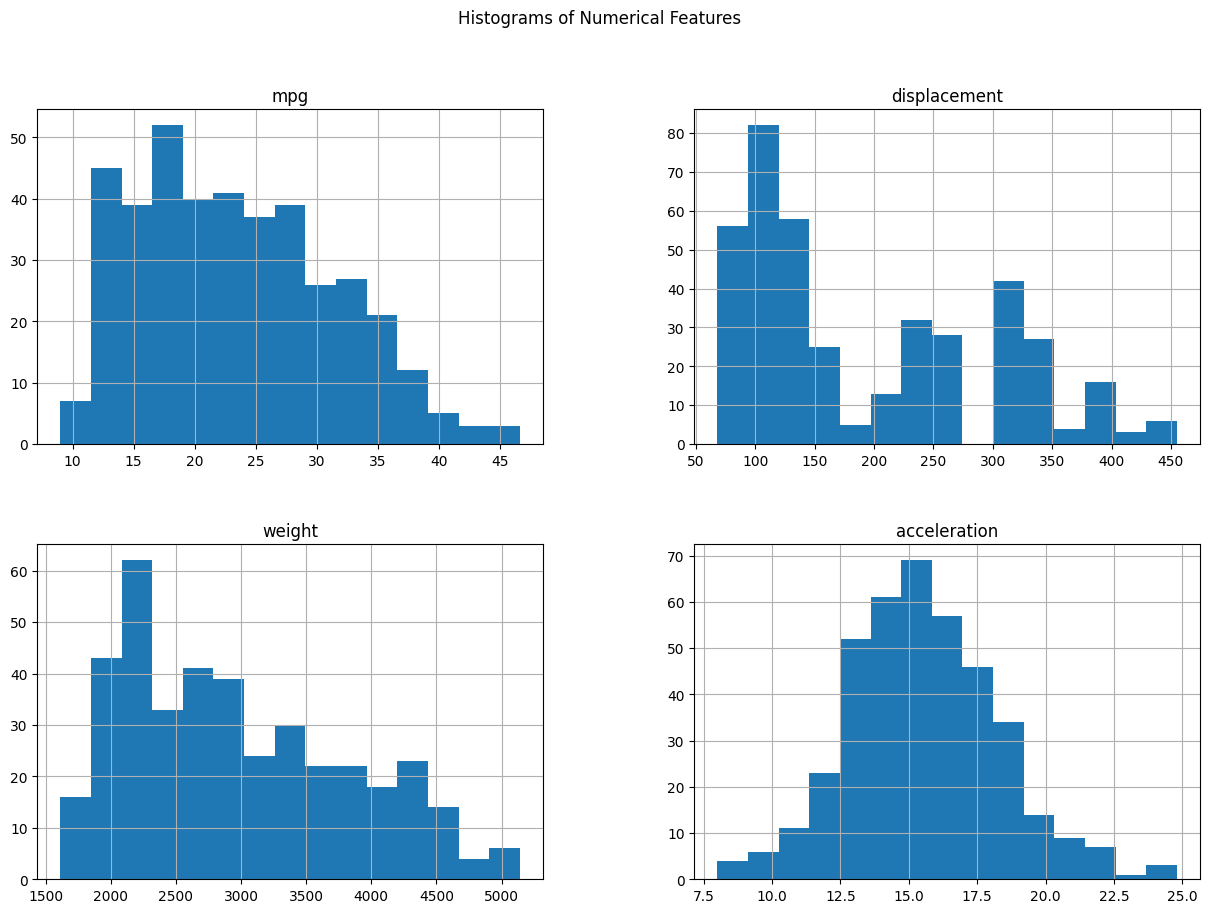

In [32]:
# Plot histograms for numerical features
dataframe[numerical_features].hist(bins=15, figsize=(15, 10))
plt.suptitle("Histograms of Numerical Features")
plt.show()

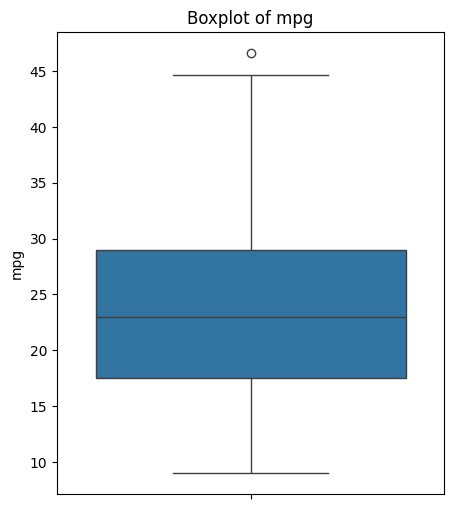

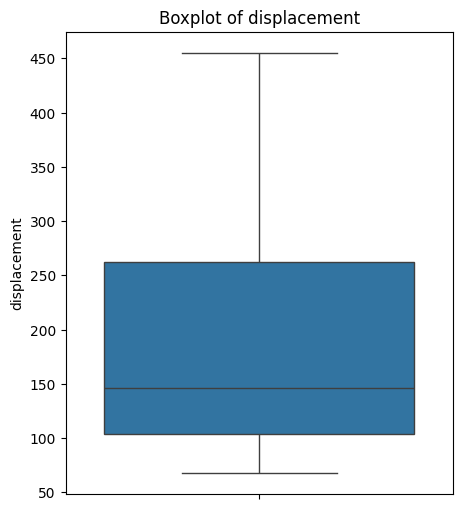

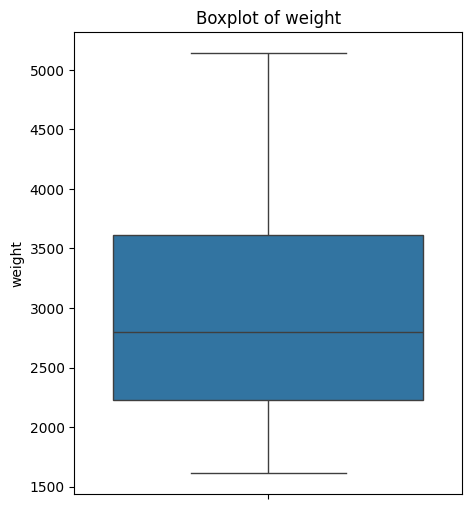

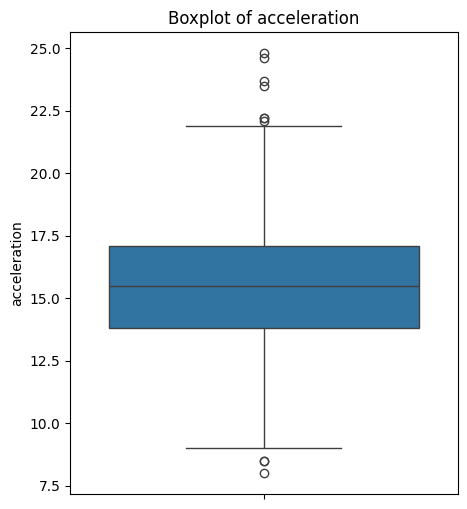

In [33]:
# Display individual vertical boxplots for each numerical feature
for feature in numerical_features:
    plt.figure(figsize=(5, 6))  # Set figure size for better visibility
    sns.boxplot(y=dataframe[feature])  # Use 'y' for vertical orientation
    plt.title(f"Boxplot of {feature}")
    plt.ylabel(feature)
    plt.show()

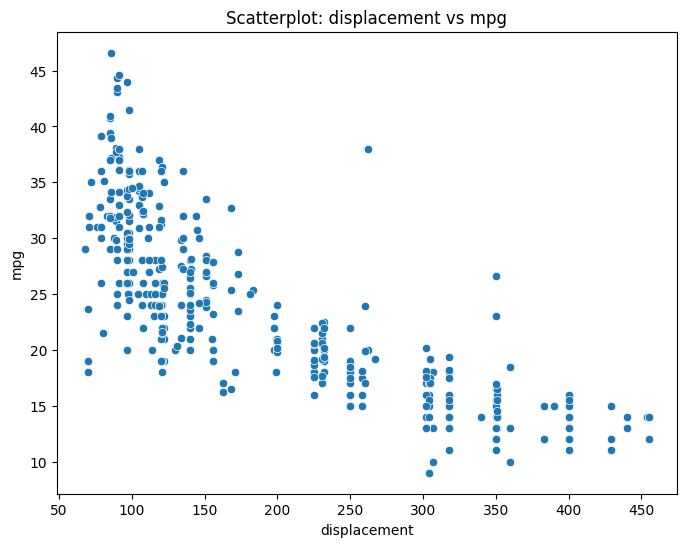

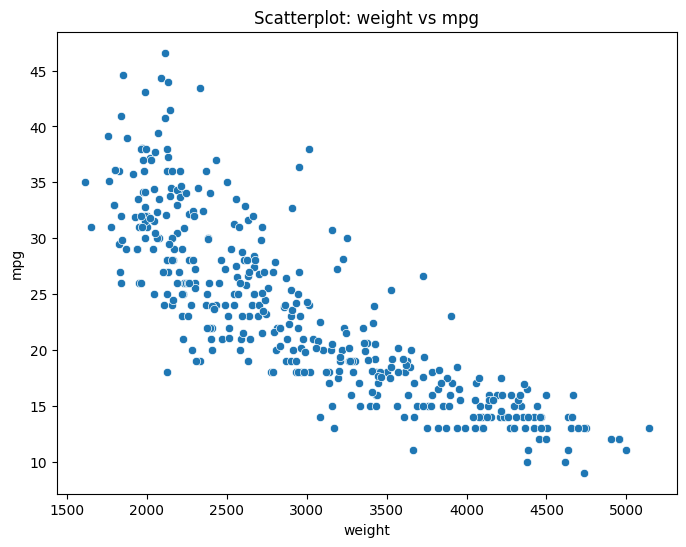

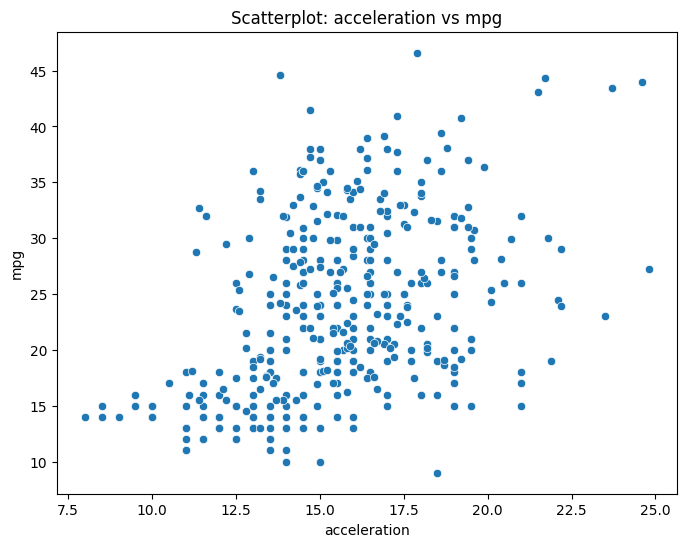

In [34]:
# Scatterplot between selected features and target
target = "mpg"  # Target variable
features_to_plot = ['displacement', 'weight', 'acceleration']  # Select features

for feature in features_to_plot:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=dataframe[feature], y=dataframe[target])
    plt.title(f"Scatterplot: {feature} vs {target}")
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.show()